In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import time

# 4.1 The Ising Model in 1d

For the dimensionless version we define the dimensionless $a = \beta J $ and $ b = \beta h$

We get for the true result:

$ Z[a,b] = \lambda_+^N+\lambda_-^N  = \left(e^{a} \left( \cosh(b)+ \sqrt{ \sinh^2(b)+e^{-4a}}\right)\right)^N + \left(e^{a} \left( \cosh(b)- \sqrt{ \sinh^2(b)+e^{-4a}}\right)\right)^N $ 

In [2]:
# Use sympy to solve 

h, T, J, N = sp.symbols(r'h T J N')
lam_p = sp.exp(J/T)*(sp.cosh(h/T) + sp.sqrt(sp.sinh(h/T)**2+sp.exp(-4*J/T))) # lambda plus
lam_m = sp.exp(J/T)*(sp.cosh(h/T) - sp.sqrt(sp.sinh(h/T)**2+sp.exp(-4*J/T))) # lamnbda minus
Z = lam_p**N+lam_m**N
M = T*sp.diff(sp.log(Z),h)
M

T*(N*((-sqrt(sinh(h/T)**2 + exp(-4*J/T)) + cosh(h/T))*exp(J/T))**N*(sinh(h/T)/T - sinh(h/T)*cosh(h/T)/(T*sqrt(sinh(h/T)**2 + exp(-4*J/T))))/(-sqrt(sinh(h/T)**2 + exp(-4*J/T)) + cosh(h/T)) + N*((sqrt(sinh(h/T)**2 + exp(-4*J/T)) + cosh(h/T))*exp(J/T))**N*(sinh(h/T)/T + sinh(h/T)*cosh(h/T)/(T*sqrt(sinh(h/T)**2 + exp(-4*J/T))))/(sqrt(sinh(h/T)**2 + exp(-4*J/T)) + cosh(h/T)))/(((-sqrt(sinh(h/T)**2 + exp(-4*J/T)) + cosh(h/T))*exp(J/T))**N + ((sqrt(sinh(h/T)**2 + exp(-4*J/T)) + cosh(h/T))*exp(J/T))**N)

In [3]:
M.simplify()

N*(((sqrt(sinh(h/T)**2 + exp(-4*J/T)) + cosh(h/T))*exp(J/T))**N - (-(sqrt(sinh(h/T)**2 + exp(-4*J/T)) - cosh(h/T))*exp(J/T))**N)*sqrt(sinh(h/T)**2 + exp(-4*J/T))*exp(4*J/T)*sinh(h/T)/((((sqrt(sinh(h/T)**2 + exp(-4*J/T)) + cosh(h/T))*exp(J/T))**N + (-(sqrt(sinh(h/T)**2 + exp(-4*J/T)) - cosh(h/T))*exp(J/T))**N)*(exp(4*J/T)*sinh(h/T)**2 + 1))

We get the dimensionless version of $\left\langle M \right\rangle$:
\begin{align} 
\left\langle M \right\rangle = N \frac {(\lambda_+^N- (-\lambda_-)^N)\sqrt{\sinh^2(b)+e^{-4a}}e^{4a} \sinh(b)}{(\lambda_+^N + (-\lambda_-)^N)(e^{4a} \sinh^2(b)+1)}
\end{align}
with 

\begin{align} 
\lambda_\pm = \left(e^{a} \left( \cosh(b) \pm \sqrt{ \sinh^2(b)+e^{-4a}}\right)\right)
\end{align}

In [92]:
def M(a,b,N):
    lam_p = np.exp(a)*(np.cosh(b) + np.sqrt(np.sinh(b)**2+np.exp(-4*a)))
    lam_m = np.exp(a)*(np.cosh(b) - np.sqrt(np.sinh(b)**2+np.exp(-4*a)))
    diff_Z_1 = N*(lam_p**N-(-lam_m)**N)*np.sqrt(np.sinh(b)**2+np.exp(-4*a))*np.exp(4*a)*np.sinh(b)
    diff_Z_2 = (lam_p**N+(-lam_m)**N)*(np.exp(4*a)*np.sinh(b)**2+1)
    return diff_Z_1/diff_Z_2

def m(a,b):
    return np.sinh(b)/np.sqrt(np.sinh(b)**2+np.exp(-4*a))

J = 0.75  # =a since beta =1
h = np.linspace(-1,1,100)
N = [1,2,4,8,16]


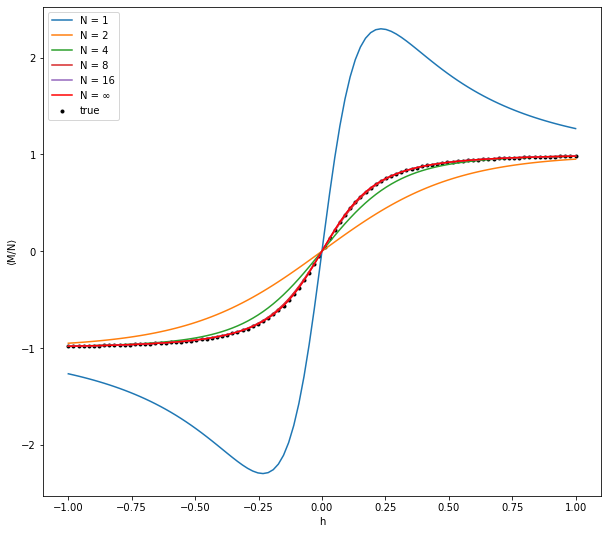

In [5]:
fig,ax =plt.subplots(figsize=(10,9))

for x in range(len(N)):
    ax.plot(h,M(J,h,N[x])/N[x] , label = f'N = {N[x]}')
    ax.set_xlabel('h')
    ax.set_ylabel('⟨M/N⟩')
ax.plot(h,M(J,h,300)/300 , label = 'N = ∞', color ='red')
ax.scatter(h,m(J,h), marker ='.', color ='black', label ='true')    
ax.legend(loc='upper left')
plt.show()
    


In [9]:
def H1d(a,sigma):
    return -a*(np.roll(sigma,-1)*sigma+np.roll(sigma,1)*sigma).sum()

def action(a,b,sigma):
    S = H1d(a,sigma)-b*sigma.sum()
    return S

[ 1 -1 -1] 3


In [23]:
def delS1d(a,b,sigma,x):
    if len(sigma)-1 in [x]:
        s = -2*a*(sigma[0]*sigma[x]+ sigma[x-1]*sigma[x])-2*b*sigma[x]
    else: 
        s = -2*a*(sigma[x+1]*sigma[x]+ sigma[x-1]*sigma[x])-2*b*sigma[x]
    return s

In [38]:
a = 0.75
b = 1
expo = np.arange(1, 10)
N =(10.0**expo)
time1 = np.zeros(len(N))
time2 = np.zeros(len(N))
for s in range(len(N)):
    sigma = np.random.choice([-1,1], size=int(N[s]))
    start1 = time.process_time()
    p = action(a,b,sigma)
    time1[s] = time.process_time() - start1
    start2 = time.process_time()
    p = delS1d(a,b,sigma,1)
    time2[s] = time.process_time() - start2

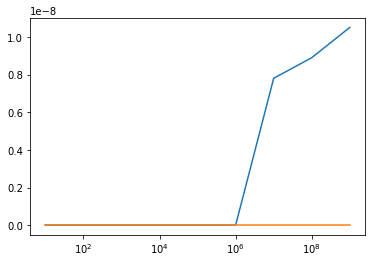

In [42]:
plt.plot(N,time1/N)
plt.plot(N,time2)
plt.xscale('log')
plt.show()

In [112]:
J = 0.75 
h = np.linspace(-1,1,20)
N = 20
sigma =  np.ones(20)

def update(sigma):
    x = np.random.choice(len(sigma), 1)
    sigma[x] = -sigma[x]
    return sigma,x

def MC(a,b,sigma,N):
    m = np.zeros(len(b))
    # start with distribution sigma
    original_sigma = sigma
    for h in range(len(b)):
        #restore sigma to original starting state
        sigma = original_sigma
        for s in range(N):
            #  x_t+1 = x_t
            new_sigma = sigma
            # calculate possible x_t+1
            ns,x = update(sigma)
            # Acceptance condition
            if np.random.uniform(low=0, high=1) < min(1,np.exp(-delS1d(a,b[h],sigma,x))):
                #  if accepted x_t+1 is new sigma
                new_sigma = ns
            else:
                #  if rejected x_t is new sigma
                pass
            sigma = new_sigma
        m[h]=sigma.sum()/N
    return m

In [113]:
MC(J,h,sigma,N)

array([ 0.4,  0.2,  0. ,  0. ,  0. ,  0. , -0.2,  0.2,  0.2, -0.4,  0.2,
        0. , -0.2,  0. ,  0. , -0.4,  0. ,  0.4, -0.6,  0. ])

In [178]:
mc_time = 1000
m_mc = np.zeros((20,mc_time))
for x in range(1):
    J = 0.75 
    h = np.linspace(-1,1,20)
    N = 20
    sigma =  np.ones(20)
    m_mc[:,x] = MC(J,h,sigma,N)

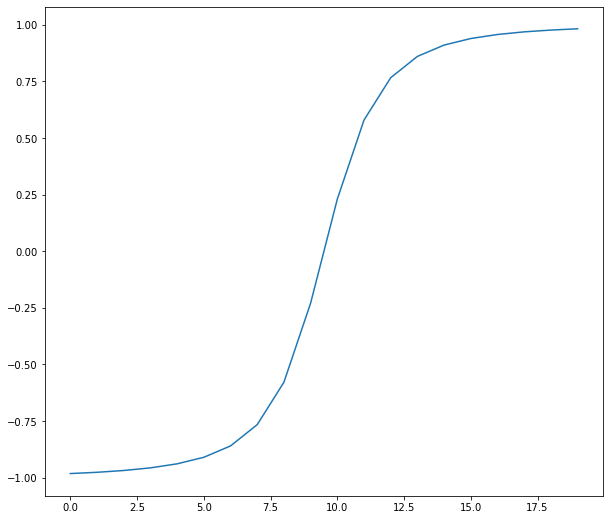

In [ ]:
fig,ax =plt.subplots(figsize=(10,9))
ax.plot(m(J,h))
plt.show()
#plt.hist(m_mc[0],density = True)
plt.hist(m_mc,stacked=True)
plt.show()
